In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv


In [3]:
# Download the Stellar Classification dataset from Kaggle
# The dataset contains astronomical observations from the
# Sloan Digital Sky Survey (SDSS).

import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17


In [4]:
# Load the CSV dataset into a pandas DataFrame
# Each row represents a celestial object and its observed features.
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv")

In [5]:
# Display the first few rows of the dataset
# Helps understand the structure and available features.
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [6]:
# Generate descriptive statistics for numerical columns
# Useful for understanding feature distributions and ranges.
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [7]:
# Display column names, data types, and non-null counts
# Helps identify missing values and feature types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [8]:
# Check the number of rows and columns in the dataset.
df.shape

(100000, 18)

In [9]:
# Check for missing values in each column
# Missing values must be handled before model training.
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Column: obj_ID
Meaning:
Unique identifier assigned to each celestial object.

Use in Model:
No

Reason:
Only an ID number. It contains no useful astronomical information.

--------------------------------------------------

Column: alpha

Meaning:
Right Ascension (RA), which represents the object's position in the sky. Similar to longitude on Earth.

Use in Model:
Yes

Reason:
The location of an object can help distinguish between stars, galaxies, and quasars.

--------------------------------------------------

Column: delta

Meaning:
Declination (DEC), which represents the object's position in the sky. Similar to latitude on Earth.

Use in Model:
Yes

Reason:
Provides spatial information about the object.

--------------------------------------------------

Column: u

Meaning:
Brightness measured through the ultraviolet filter.

Use in Model:
Yes

Reason:
Different celestial objects emit different amounts of ultraviolet light.

--------------------------------------------------

Column: g

Meaning:
Brightness measured through the green filter.

Use in Model:
Yes

Reason:
Helps describe the object's spectral characteristics.

--------------------------------------------------

Column: r

Meaning:
Brightness measured through the red filter.

Use in Model:
Yes

Reason:
Useful for distinguishing different object types.

--------------------------------------------------

Column: i

Meaning:
Brightness measured through the near-infrared filter.

Use in Model:
Yes

Reason:
Provides additional spectral information.

--------------------------------------------------

Column: z

Meaning:
Brightness measured through the infrared filter.

Use in Model:
Yes

Reason:
Important for identifying distant objects and spectral patterns.

--------------------------------------------------

Column: run_ID

Meaning:
Identifier of the SDSS survey run during which the object was observed.

Use in Model:
No

Reason:
Administrative information only.

--------------------------------------------------

Column: rerun_ID

Meaning:
Identifier of the data processing version.

Use in Model:
No

Reason:
Does not describe the object itself.

--------------------------------------------------

Column: cam_col

Meaning:
Camera column used during observation.

Use in Model:
No

Reason:
Instrument information, not object information.

--------------------------------------------------

Column: field_ID

Meaning:
Field number of the sky image.

Use in Model:
Usually No

Reason:
Mostly observational metadata.

--------------------------------------------------

Column: spec_obj_ID

Meaning:
Unique identifier for the spectroscopic observation.

Use in Model:
No

Reason:
Just an identifier.

--------------------------------------------------

Column: class

Meaning:
Type of celestial object.

Possible values:
STAR
GALAXY
QSO

Use in Model:
Target Variable

Reason:
This is what the model is trying to predict.

--------------------------------------------------

Column: redshift

Meaning:
Amount by which light has shifted toward longer wavelengths due to expansion of the universe.

Use in Model:
Yes

Reason:
One of the most important features in the dataset.
Stars generally have low redshift, galaxies moderate redshift, and quasars often have high redshift.

--------------------------------------------------

Column: plate

Meaning:
Spectroscopic plate identifier.

Use in Model:
No

Reason:
Administrative identifier only.

--------------------------------------------------

Column: MJD

Meaning:
Modified Julian Date indicating when the observation was made.

Use in Model:
Usually No

Reason:
Observation date generally does not determine object class.

--------------------------------------------------

Column: fiber_ID

Meaning:
Fiber optic cable identifier used for spectroscopy.

Use in Model:
No

Reason:
Contains no physical information about the object.

--------------------------------------------------

Features to use in model training:
alpha
delta
u
g
r
i
z
redshift

Target:
class

Columns to Drop:
obj_ID
run_ID
rerun_ID
cam_col
field_ID
spec_obj_ID
plate
MJD
fiber_ID

In [10]:
# Remove identifier and metadata columns that do not
# contribute meaningful information for classification.

# These columns uniquely identify observations but do not help distinguish between stars, galaxies, and quasars.
df_new = df.drop(['obj_ID','run_ID','rerun_ID','cam_col','field_ID','spec_obj_ID','plate','MJD','fiber_ID'], axis=1)

In [11]:
# Display remaining columns after feature selection.
df_new.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift'], dtype='object')

In [12]:
# Display the unique classes present in the target variable.
df_new['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [13]:
# Convert categorical class labels into numerical values for classification , generally used in machine learning algorithms.
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(df_new['class'])

In [28]:
# Display mapping between original class names and
# encoded numerical labels.
print(dict(zip(encoder.classes_, range(len(encoder.classes_)))))

{'GALAXY': 0, 'QSO': 1, 'STAR': 2}


In [15]:
# Separate features and target variable.
# X contains all variables which uniquely identify the target(inputs).
# y contains the encoded class labels(target).
X = df_new.drop(['class'] , axis = 1)
print(X.head)
print(type(X))

<bound method NDFrame.head of             alpha      delta         u         g         r         i  \
0      135.689107  32.494632  23.87882  22.27530  20.39501  19.16573   
1      144.826101  31.274185  24.77759  22.83188  22.58444  21.16812   
2      142.188790  35.582444  25.26307  22.66389  20.60976  19.34857   
3      338.741038  -0.402828  22.13682  23.77656  21.61162  20.50454   
4      345.282593  21.183866  19.43718  17.58028  16.49747  15.97711   
...           ...        ...       ...       ...       ...       ...   
99995   39.620709  -2.594074  22.16759  22.97586  21.90404  21.30548   
99996   29.493819  19.798874  22.69118  22.38628  20.45003  19.75759   
99997  224.587407  15.700707  21.16916  19.26997  18.20428  17.69034   
99998  212.268621  46.660365  25.35039  21.63757  19.91386  19.07254   
99999  196.896053  49.464643  22.62171  21.79745  20.60115  20.00959   

              z  redshift  
0      18.79371  0.634794  
1      21.61427  0.779136  
2      18.94827  0.64

In [16]:
# Split dataset into training and testing sets.
# 80% Training Data
# 20% Testing Data
from sklearn.model_selection import train_test_split 
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.2 , random_state = 1)

In [17]:
# Train an XGBoost classifier.
# RandomizedsearchCV is used to find the best combination of hyperparameters through cross-validation.
# Parameters being tuned:
# n_estimators
# max_depth
# learning_rate
# subsample
# colsample_bytree


from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

param_dist = {
    'n_estimators': [300, 500, 1000, 1500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=1,
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=3, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [300, 500, 1000, 1500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=1, scoring='accuracy')

In [18]:
# Retrieve the best performing model obtained from randomizedsearchCV
best_model = random_search.best_estimator_

In [19]:
# Generate predictions on unseen test data.
y_pred = best_model.predict(X_test)

In [20]:
# Evaluate model performance using:
# Precision
# Recall
# F1 Score
# Support
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11871
           1       0.96      0.94      0.95      3821
           2       0.99      0.99      0.99      4308

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



In [24]:
# Generate confusion matrix.
# Rows represent actual classes.
# Columns represent predicted classes.
# Helps identify which classes are being confused.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11687   144    40]
 [  225  3595     1]
 [   34     0  4274]]


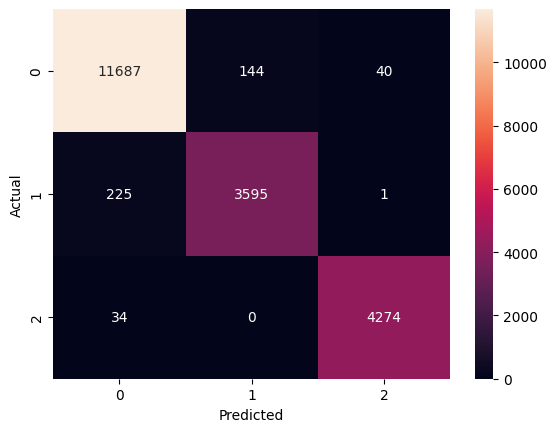

In [25]:
# Visualize the confusion matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Determine which astronomical features contribute most to the model's predictions.
# Higher importance indicates greater influence on final decisions.

import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
7  redshift    0.831888
3         g    0.058020
6         z    0.030687
2         u    0.027382
5         i    0.018253
4         r    0.013463
1     delta    0.010532
0     alpha    0.009776


In [31]:
# Save the trained model for future use.

# The saved model can be loaded later without retraining.
import joblib

joblib.dump(best_model, '/kaggle/working/stellar_classifier.pkl')

['/kaggle/working/stellar_classifier.pkl']